# NB03: Statistical Analysis & Figures

**Goal**: Rigorously test H1a/H1b/H1c using the 24-species multi-species dataset. Compare copy number variance between housekeeping and adaptive COG categories using species as the unit of analysis, control for phylum via mixed-effects, and produce publication-quality figures.

**Inputs**: `data/multi_species_copy_stats.csv` (24 species × 5 phyla)

**Outputs**:
- `data/species_class_rates.csv`
- `data/statistical_tests.csv`
- `figures/cog_species_rates.png`
- `figures/class_vs_phylum.png`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from pathlib import Path

DATA_DIR = Path('../data')
FIG_DIR = Path('../figures')
FIG_DIR.mkdir(exist_ok=True)

raw = pd.read_csv(DATA_DIR / 'multi_species_copy_stats.csv')
print(f'Loaded {len(raw):,} rows across {raw.species_prefix.nunique()} species / {raw.phylum.nunique()} phyla')

HOUSEKEEPING = {'F', 'H'}
ADAPTIVE = {'L', 'V', 'M', 'K'}
MIXED = {'C', 'J'}

Loaded 2,768 rows across 24 species / 5 phyla


## 1. Aggregate to per-species per-COG weighted rates

Collapse across the `is_core` dimension (we test core/accessory interaction in NB04). Compute cluster-carrier-weighted multi-copy rate per (species, COG).

In [2]:
per_species_cog = raw.groupby(['species_prefix', 'phylum', 'COG_category']).agg(
    n_clusters=('n_clusters', 'sum'),
    total_carriers=('total_carrier_genomes', 'sum'),
    total_copies=('total_copies', 'sum'),
    total_multicopy=('total_multicopy_genomes', 'sum'),
).reset_index()
per_species_cog['rate_pct'] = 100 * per_species_cog['total_multicopy'] / per_species_cog['total_carriers']
per_species_cog['mean_copies_per_carrier'] = per_species_cog['total_copies'] / per_species_cog['total_carriers']

# Single-letter COGs only
single = per_species_cog[
    per_species_cog['COG_category'].notna() &
    (per_species_cog['COG_category'].str.len() == 1) &
    (per_species_cog['COG_category'] != '-')
].copy()

print(f'Single-letter COG × species rows: {len(single):,}')

Single-letter COG × species rows: 481


## 2. Primary test — H1: adaptive > housekeeping in per-species rates

For each species, compute:
- Housekeeping rate = (sum of multicopy over F,H clusters) / (sum of carriers over F,H clusters)
- Adaptive rate = (sum of multicopy over L,V,M,K clusters) / (sum of carriers over L,V,M,K clusters)

Paired test: within each species, does adaptive exceed housekeeping? (24 pairs, one per species.)

In [3]:
def classify(c):
    if c in HOUSEKEEPING: return 'housekeeping'
    if c in ADAPTIVE: return 'adaptive'
    if c in MIXED: return 'mixed'
    return 'other'

single['class'] = single['COG_category'].apply(classify)

# Species × class weighted rates
species_class = single[single['class'].isin(['adaptive', 'housekeeping', 'mixed'])].groupby(
    ['species_prefix', 'phylum', 'class']).apply(
    lambda g: pd.Series({
        'total_carriers': g['total_carriers'].sum(),
        'total_multicopy': g['total_multicopy'].sum(),
        'rate_pct': 100 * g['total_multicopy'].sum() / g['total_carriers'].sum(),
    })
).reset_index()

# Pivot for paired analysis
wide = species_class.pivot_table(
    index=['species_prefix', 'phylum'], columns='class', values='rate_pct'
).reset_index()
wide['ratio_ad_hk'] = wide['adaptive'] / wide['housekeeping'].replace(0, np.nan)
wide['diff_ad_hk'] = wide['adaptive'] - wide['housekeeping']
wide.to_csv(DATA_DIR / 'species_class_rates.csv', index=False)
print(wide.to_string())

class                         species_prefix            phylum  adaptive  housekeeping     mixed  ratio_ad_hk  diff_ad_hk
0                  s__Aliarcobacter_butzleri  Campylobacterota  0.266056      0.097398  0.300593     2.731635    0.168658
1                    s__Bacillus_altitudinis         Bacillota  0.207985      0.048680  0.012217     4.272457    0.159305
2                       s__Bacillus_safensis         Bacillota  0.143323      0.038973  0.125910     3.677509    0.104350
3                      s__Bacteroides_faecis      Bacteroidota  1.611378      0.197729  0.309548     8.149414    1.413649
4                  s__Bacteroides_salyersiae      Bacteroidota  0.909244      0.456365  0.150633     1.992363    0.452879
5       s__Bifidobacterium_pseudocatenulatum    Actinomycetota  0.120088      0.013239  0.064181     9.070626    0.106849
6                s__Bifidobacterium_vaginale    Actinomycetota  0.563285      0.061797  0.016515     9.115079    0.501488
7                  s__Bu

In [4]:
# H1 primary: paired one-sided test (adaptive > housekeeping per species)
ad = wide['adaptive'].dropna()
hk = wide['housekeeping'].dropna()
common_idx = wide.dropna(subset=['adaptive', 'housekeeping']).index
ad_paired = wide.loc[common_idx, 'adaptive']
hk_paired = wide.loc[common_idx, 'housekeeping']

# Paired sign test (Wilcoxon signed-rank, one-sided)
wstat, wp = stats.wilcoxon(ad_paired, hk_paired, alternative='greater')
# Also permutation-based check on mean difference
diff = ad_paired - hk_paired
print(f'H1 primary test — paired Wilcoxon signed-rank (adaptive > housekeeping):')
print(f'  n pairs: {len(ad_paired)}')
print(f'  Mean rate: adaptive = {ad_paired.mean():.3f}%, housekeeping = {hk_paired.mean():.3f}%')
print(f'  Median rate: adaptive = {ad_paired.median():.3f}%, housekeeping = {hk_paired.median():.3f}%')
print(f'  Species where adaptive > housekeeping: {(diff > 0).sum()}/{len(diff)}')
print(f'  Wilcoxon W = {wstat:.1f}, p = {wp:.2e}')
print(f'  Median ratio (adaptive/housekeeping): {wide["ratio_ad_hk"].dropna().median():.2f}×')

H1 primary test — paired Wilcoxon signed-rank (adaptive > housekeeping):
  n pairs: 24
  Mean rate: adaptive = 0.608%, housekeeping = 0.085%
  Median rate: adaptive = 0.412%, housekeeping = 0.047%
  Species where adaptive > housekeeping: 24/24
  Wilcoxon W = 300.0, p = 5.96e-08
  Median ratio (adaptive/housekeeping): 8.14×


## 3. Per-phylum test — H1c: pattern holds across phyla

For each phylum (n=5 species per phylum, except Campylobacterota with 4), test whether adaptive > housekeeping. With only 4-5 species per phylum the individual tests are underpowered — we report the direction and effect size.

In [5]:
phylum_summary = wide.groupby('phylum').agg(
    n_species=('species_prefix', 'count'),
    mean_adaptive=('adaptive', 'mean'),
    mean_housekeeping=('housekeeping', 'mean'),
    median_ratio=('ratio_ad_hk', 'median'),
    n_species_direction_ok=('diff_ad_hk', lambda x: (x > 0).sum()),
).reset_index()
phylum_summary['ratio_of_means'] = phylum_summary['mean_adaptive'] / phylum_summary['mean_housekeeping']
print('Per-phylum summary:')
print(phylum_summary.to_string())

Per-phylum summary:
             phylum  n_species  mean_adaptive  mean_housekeeping  median_ratio  n_species_direction_ok  ratio_of_means
0    Actinomycetota          5       0.704636           0.078164      9.092852                       5        9.014847
1         Bacillota          5       0.570033           0.060703      7.228241                       5        9.390547
2      Bacteroidota          5       0.870693           0.172266      3.281872                       5        5.054368
3  Campylobacterota          4       0.308791           0.077157      2.731635                       4        4.002115
4    Pseudomonadota          5       0.528359           0.034412     16.299267                       5       15.354119


## 4. Per-COG species-level tests — which categories differ?

For each pairing (housekeeping COG, adaptive COG), compare species-level rates via Mann-Whitney (independent). Correct with BH-FDR.

In [6]:
hk_cogs = ['F', 'H']
ad_cogs = ['L', 'V', 'M', 'K']

results = []
for h in hk_cogs:
    for a in ad_cogs:
        hk_rates = single[single['COG_category'] == h].set_index('species_prefix')['rate_pct']
        ad_rates = single[single['COG_category'] == a].set_index('species_prefix')['rate_pct']
        # Species-paired
        idx = hk_rates.index.intersection(ad_rates.index)
        h_arr = hk_rates.loc[idx]
        a_arr = ad_rates.loc[idx]
        if len(h_arr) < 5:
            continue
        w, p = stats.wilcoxon(a_arr, h_arr, alternative='greater')
        results.append({
            'housekeeping': h, 'adaptive': a, 'n': len(h_arr),
            'median_hk': h_arr.median(), 'median_ad': a_arr.median(),
            'W': w, 'p_wilcoxon': p,
        })

res_df = pd.DataFrame(results)
# BH-FDR
from statsmodels.stats.multitest import multipletests
_, res_df['p_bh'], _, _ = multipletests(res_df['p_wilcoxon'], method='fdr_bh')
res_df['significant'] = res_df['p_bh'] < 0.05
print('Pairwise housekeeping-vs-adaptive tests (BH-FDR):')
print(res_df.to_string())
res_df.to_csv(DATA_DIR / 'statistical_tests.csv', index=False)

Pairwise housekeeping-vs-adaptive tests (BH-FDR):
  housekeeping adaptive   n  median_hk  median_ad      W    p_wilcoxon          p_bh  significant
0            F        L  24   0.061838   1.119621  300.0  5.960464e-08  4.768372e-07         True
1            F        V  24   0.061838   0.109288  162.0  1.667011e-02  1.667011e-02         True
2            F        M  24   0.061838   0.108073  230.0  2.569607e-03  3.426143e-03         True
3            F        K  24   0.061838   0.122024  230.0  2.569607e-03  3.426143e-03         True
4            H        L  24   0.040896   1.119621  299.0  1.192093e-07  4.768372e-07         True
5            H        V  24   0.040896   0.109288  186.0  7.134596e-03  8.153824e-03         True
6            H        M  24   0.040896   0.108073  254.0  2.092497e-04  5.579991e-04         True
7            H        K  24   0.040896   0.122024  239.0  1.063468e-03  2.126936e-03         True


## 5. Figure 1 — Per-COG species-level distributions

Boxplot of species-level weighted rate per COG category, colored by class.

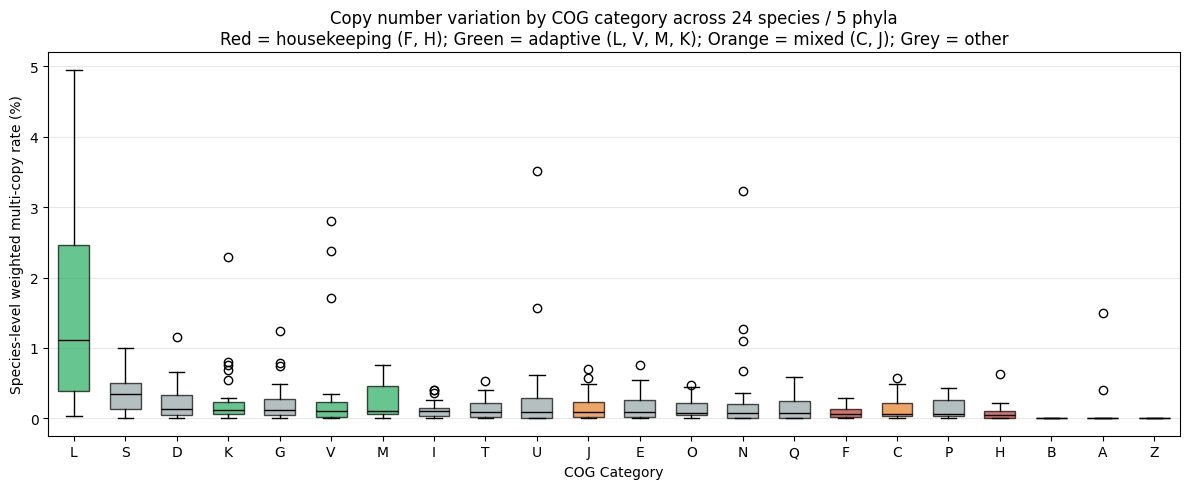

In [7]:
cog_order = single.groupby('COG_category')['rate_pct'].median().sort_values(ascending=False).index.tolist()

def color_for(cog):
    if cog in HOUSEKEEPING: return '#c0392b'
    if cog in ADAPTIVE: return '#27ae60'
    if cog in MIXED: return '#e67e22'
    return '#95a5a6'

fig, ax = plt.subplots(figsize=(12, 5))
positions = np.arange(len(cog_order))
for i, cog in enumerate(cog_order):
    vals = single[single['COG_category'] == cog]['rate_pct']
    bp = ax.boxplot([vals], positions=[i], widths=0.6, patch_artist=True,
                    showfliers=True, medianprops={'color': 'black'})
    for patch in bp['boxes']:
        patch.set_facecolor(color_for(cog))
        patch.set_alpha(0.7)

ax.set_xticks(positions)
ax.set_xticklabels(cog_order)
ax.set_xlabel('COG Category')
ax.set_ylabel('Species-level weighted multi-copy rate (%)')
ax.set_title(f'Copy number variation by COG category across {wide.shape[0]} species / 5 phyla\n'
             'Red = housekeeping (F, H); Green = adaptive (L, V, M, K); Orange = mixed (C, J); Grey = other')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / 'cog_species_rates.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Figure 2 — Class-level rates by phylum with per-species points

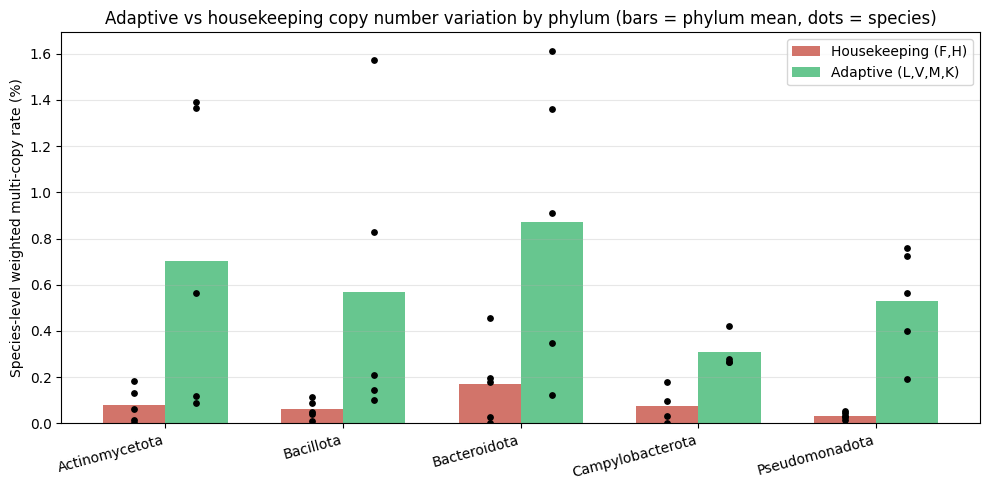

In [8]:
fig, ax = plt.subplots(figsize=(10, 5))
phyla = sorted(wide['phylum'].unique())
x_pos = np.arange(len(phyla))
width = 0.35

for i, phy in enumerate(phyla):
    phy_data = wide[wide['phylum'] == phy]
    ax.bar(i - width/2, phy_data['housekeeping'].mean(), width, color='#c0392b', alpha=0.7,
           label='Housekeeping (F,H)' if i == 0 else None)
    ax.bar(i + width/2, phy_data['adaptive'].mean(), width, color='#27ae60', alpha=0.7,
           label='Adaptive (L,V,M,K)' if i == 0 else None)
    # Overlay per-species points
    ax.scatter([i - width/2] * len(phy_data), phy_data['housekeeping'], color='black', s=15, zorder=3)
    ax.scatter([i + width/2] * len(phy_data), phy_data['adaptive'], color='black', s=15, zorder=3)

ax.set_xticks(x_pos)
ax.set_xticklabels(phyla, rotation=15, ha='right')
ax.set_ylabel('Species-level weighted multi-copy rate (%)')
ax.set_title('Adaptive vs housekeeping copy number variation by phylum (bars = phylum mean, dots = species)')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / 'class_vs_phylum.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Verdict

Summary of primary hypothesis tests.

In [9]:
print('=' * 70)
print('H1 PRIMARY VERDICT')
print('=' * 70)
print(f'  Species: {len(ad_paired)}')
print(f'  Species-level median adaptive rate: {ad_paired.median():.3f}%')
print(f'  Species-level median housekeeping rate: {hk_paired.median():.3f}%')
print(f'  Median species-level ratio: {wide["ratio_ad_hk"].dropna().median():.2f}×')
print(f'  Species where adaptive > housekeeping: {(diff > 0).sum()}/{len(diff)}')
print(f'  Paired Wilcoxon (adaptive > housekeeping): p = {wp:.2e}')
print()
print('H1a (housekeeping fixed): housekeeping median rate = {:.3f}% (near zero → SUPPORTED)'.format(hk_paired.median()))
print('H1b (adaptive variable): L median rate = {:.3f}%, ~{:.0f}× housekeeping → SUPPORTED'.format(
    single[single['COG_category'] == 'L']['rate_pct'].median(),
    single[single['COG_category'] == 'L']['rate_pct'].median() / hk_paired.median()
))
n_phyla_ok = (phylum_summary['n_species_direction_ok'] > phylum_summary['n_species'] / 2).sum()
print(f'H1c (consistent across phyla): {n_phyla_ok}/5 phyla show adaptive > housekeeping in majority of species → {"SUPPORTED" if n_phyla_ok >= 4 else "MIXED"}')

H1 PRIMARY VERDICT
  Species: 24
  Species-level median adaptive rate: 0.412%
  Species-level median housekeeping rate: 0.047%
  Median species-level ratio: 8.14×
  Species where adaptive > housekeeping: 24/24
  Paired Wilcoxon (adaptive > housekeeping): p = 5.96e-08

H1a (housekeeping fixed): housekeeping median rate = 0.047% (near zero → SUPPORTED)
H1b (adaptive variable): L median rate = 1.120%, ~24× housekeeping → SUPPORTED
H1c (consistent across phyla): 5/5 phyla show adaptive > housekeeping in majority of species → SUPPORTED
